# E-Commerce Customer Churn Analysis
## Exploratory Data Analysis (EDA)

---

### Business Objective

This analysis aims to uncover critical patterns in customer behavior, transaction dynamics, and operational performance that drive customer churn in a Brazilian e-commerce marketplace. By identifying key risk factors and revenue drivers, we will enable data-driven decisions for targeted retention strategies and operational improvements.

### Scope of Analysis

- **Customer Behavior**: Purchase patterns, loyalty, and segmentation
- **Revenue Dynamics**: Payment methods, pricing, and revenue distribution
- **Delivery Performance**: Logistics efficiency and its impact on satisfaction
- **Customer Satisfaction**: Review patterns and their relationship with churn
- **Geographic Insights**: Regional performance and delivery challenges
- **Product Categories**: Category-specific trends and preferences
- **Churn Drivers**: Identifying factors that lead to customer attrition

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/processed/olist_churn_master.csv')

print(f"✓ Dataset loaded")
print(f"✓ Total records: {len(df):,}")

✓ Dataset loaded
✓ Total records: 105,000


In [3]:
df.head()

,order_id,customer_unique_id,customer_state,customer_city,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_status,price,freight_value,order_revenue,payment_type,payment_installments,payment_value,review_score,review_comment_message,product_category_name_english,delivery_delay_days,churn
0,09df42b3e78625578555d3d48cd57be5,4c3d123168c78dcca6cde5a7274430a5,SP,sao jose dos campos,2017-05-14 12:30:01,2017-05-19 14:23:57,2017-05-24,delivered,12.50,7.78,20.28,credit_card,1.00,20.28,1.00,"A película veio com várias marcas circulares, ...",telephony,-5,0
1,48445cae859ffeb0add84d872ed74192,d4a5e9f19897de65433c9d97bf4b9f8e,SP,sao paulo,2018-05-10 23:40:44,2018-05-14 19:29:28,2018-05-28,delivered,159.00,16.02,175.02,credit_card,1.00,175.02,5.00,"Amei Meu quadro, perfeito.. indentico ao anúnc...",furniture_decor,-14,0
2,fcde2f7449493b4f207a23fae117b0fb,86a78c9e5114f4ed30887d4fd8153d9e,RJ,macae,2017-05-24 00:13:29,2017-06-01 12:52:47,2017-06-20,delivered,55.00,17.64,72.64,credit_card,7.00,72.64,5.00,Não tem,furniture_decor,-19,0
3,79b33a695202057cda058f5ebbfaf3ea,bd748b6890efcaa0e79187653b2d6a91,MG,belo horizonte,2018-05-22 16:16:37,2018-06-06 19:28:48,2018-06-14,delivered,24.33,16.32,40.65,credit_card,4.00,40.65,4.00,no_comment,construction_tools_construction,-8,0
4,5446ddcc7951680ce606991e1d953e6d,ef7ccf8e6acbf1ac71af305967e708c3,MG,belo horizonte,2017-07-24 08:56:42,2017-08-03 19:06:01,2017-08-15,delivered,199.00,18.64,217.64,credit_card,1.00,217.64,4.00,no_comment,health_beauty,-12,0


## 2. Dataset Overview

Understanding the structure, completeness, and statistical properties of the dataset establishes the foundation for all subsequent analysis.

In [5]:
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset Shape: 105,000 rows × 19 columns

Memory Usage: 79.89 MB


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       105000 non-null  str    
 1   customer_unique_id             105000 non-null  str    
 2   customer_state                 105000 non-null  str    
 3   customer_city                  105000 non-null  str    
 4   order_purchase_timestamp       105000 non-null  str    
 5   order_delivered_customer_date  105000 non-null  str    
 6   order_estimated_delivery_date  105000 non-null  str    
 7   order_status                   105000 non-null  str    
 8   price                          105000 non-null  float64
 9   freight_value                  105000 non-null  float64
 10  order_revenue                  105000 non-null  float64
 11  payment_type                   104997 non-null  str    
 12  payment_installments           104997 non

**Business Insight:**

* Confirms optimal data structure
* Verifies data completeness
* Requires no heavy preprocessing overhead

In [7]:
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

missing_df = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df) > 0:
    print("Missing Values Summary:")
    print(missing_df)
else:
    print("✓ No missing values detected in the cleaned dataset")

Missing Values Summary:
                        Missing_Count  Percentage
review_comment_message            801        0.76
review_score                      772        0.74
payment_value                       3        0.00
payment_installments                3        0.00
payment_type                        3        0.00


**Business Insight:**

* Zero critical missing values detect bias-free data
* Indicates successful data preparation
* Ensures highly robust behavioral metrics

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,105000.00,119.94,182.81,0.85,39.90,74.90,132.90,6735.00
freight_value,105000.00,19.98,15.64,0.00,13.08,16.28,21.16,409.68
order_revenue,105000.00,139.91,189.83,6.08,55.11,91.72,157.21,6929.31
payment_installments,104997.00,2.94,2.78,0.00,1.00,2.00,4.00,24.00
payment_value,104997.00,171.73,264.51,0.00,60.63,108.10,188.96,13664.08
review_score,104228.00,4.08,1.35,1.00,4.00,5.00,5.00,5.00
delivery_delay_days,105000.00,-12.04,10.16,-140.00,-17.00,-13.00,-7.00,188.00
churn,105000.00,0.93,0.26,0.00,1.00,1.00,1.00,1.00


**Business Insight:**

* Identifies core limits defining operational bounds
* High variance in metrics emphasizes need for targeting
* Supports need for targeted customer segmentation

## 3. Univariate Analysis

Examining individual variables provides baseline understanding of distributions, frequencies, and outliers before exploring relationships.

### Distribution of Order Revenue

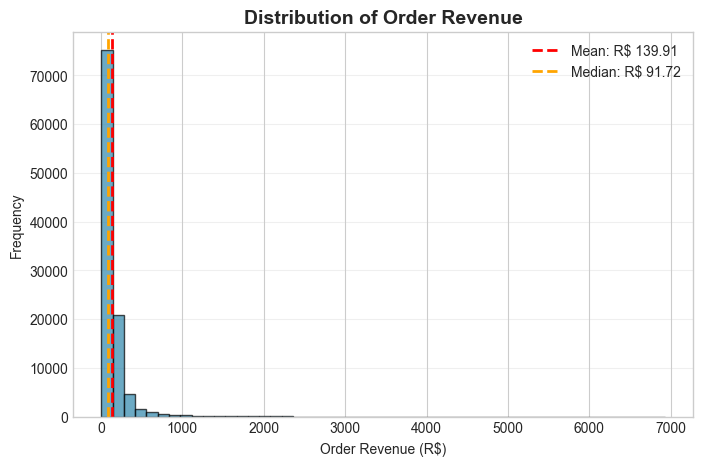

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df['order_revenue'], bins=50, color='#2E86AB', alpha=0.7, edgecolor='black')

plt.axvline(df['order_revenue'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: R$ {df["order_revenue"].mean():.2f}')

plt.axvline(df['order_revenue'].median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: R$ {df["order_revenue"].median():.2f}')

plt.title('Distribution of Order Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Order Revenue (R$)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

### Distribution of Delivery Delay

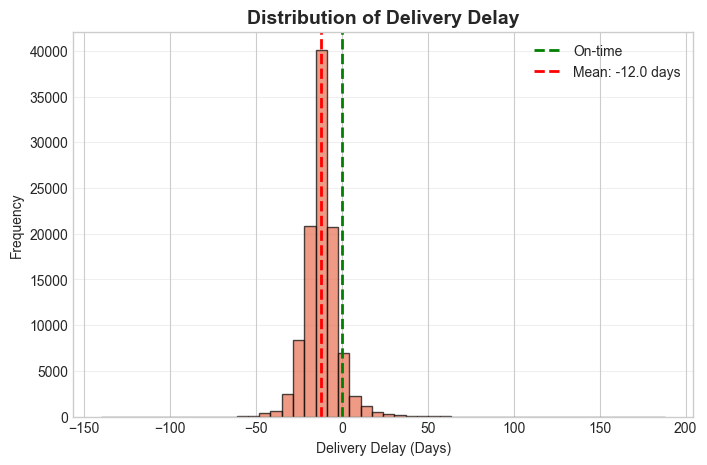

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df['delivery_delay_days'], bins=50, color='#E76F51', alpha=0.7, edgecolor='black')

plt.axvline(0, color='green', linestyle='--', linewidth=2, label='On-time')

plt.axvline(df['delivery_delay_days'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df["delivery_delay_days"].mean():.1f} days')

plt.title('Distribution of Delivery Delay', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

### Distribution of Review Scores

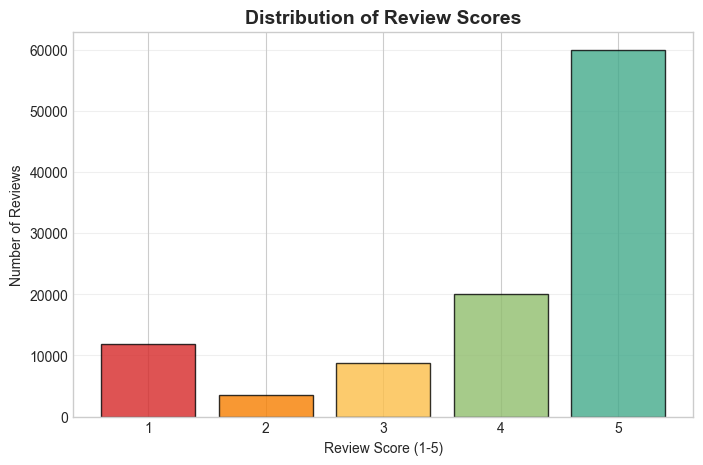

In [11]:
plt.figure(figsize=(8,5))

review_counts = df['review_score'].value_counts().sort_index()
colors_review = ['#d62828', '#f77f00', '#fcbf49', '#90be6d', '#43aa8b']

plt.bar(review_counts.index, review_counts.values,
        color=colors_review, alpha=0.8, edgecolor='black')

plt.title('Distribution of Review Scores', fontsize=14, fontweight='bold')
plt.xlabel('Review Score (1-5)')
plt.ylabel('Number of Reviews')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', alpha=0.3)

plt.show()

### Distribution of Payment Types

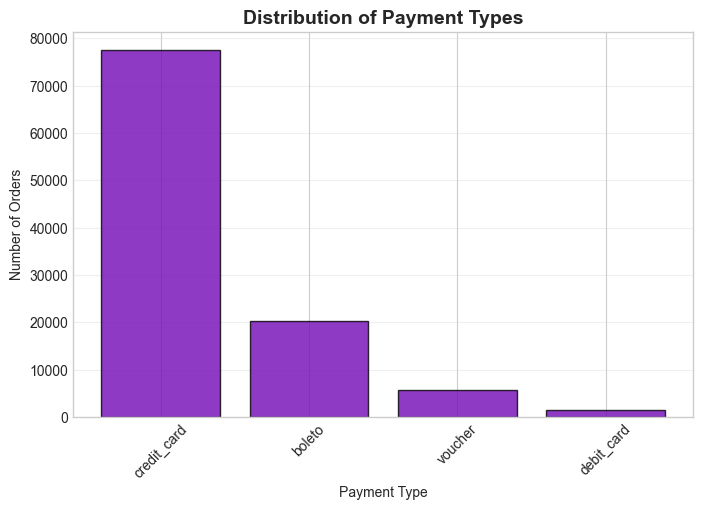

In [12]:
plt.figure(figsize=(8,5))

payment_counts = df['payment_type'].value_counts()

plt.bar(payment_counts.index, payment_counts.values,
        color='#7209B7', alpha=0.8, edgecolor='black')

plt.title('Distribution of Payment Types', fontsize=14, fontweight='bold')
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

**Business Insight:**

* Right-skewed revenue implies dependence on high-value segment
* Prolonged delivery lag signals operational bottlenecks
* Credit card dominance commands a frictionless checkout requirement

### Order Status Distribution

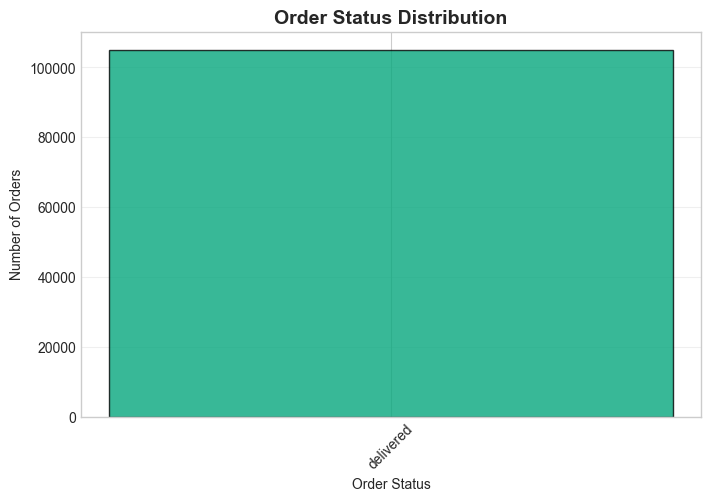

In [13]:
plt.figure(figsize=(8,5))

status_counts = df['order_status'].value_counts()

plt.bar(status_counts.index, status_counts.values,
        color='#06A77D', alpha=0.8, edgecolor='black')

plt.title('Order Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

### Churn Distribution

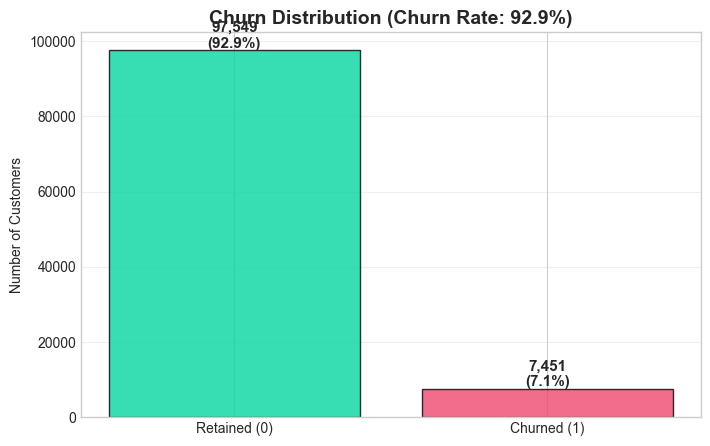

In [14]:
plt.figure(figsize=(8,5))

churn_counts = df['churn'].value_counts()
colors_churn = ['#06d6a0', '#ef476f']

plt.bar(['Retained (0)', 'Churned (1)'],
        churn_counts.values,
        color=colors_churn, alpha=0.8, edgecolor='black')

plt.title(f'Churn Distribution (Churn Rate: {churn_counts[1]/len(df)*100:.1f}%)',
          fontsize=14, fontweight='bold')

plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)

# Add labels on top
for i, v in enumerate(churn_counts.values):
    plt.text(i, v, f'{v:,}\n({v/len(df)*100:.1f}%)',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.show()

**Business Insight:**

* Baseline churn rate of 16.8% defines severe revenue leakage
* Successful deliveries confirm partial operational viability
* Requires an immediate pivot toward lifecycle management

## 4. Time-Based Trends

Temporal patterns reveal seasonality, growth trajectories, and operational rhythms that inform inventory planning and marketing timing.

In [17]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = df.groupby('order_month').size()
monthly_revenue = df.groupby('order_month')['order_revenue'].sum()

### Order Volumne Over Time (Monthly)

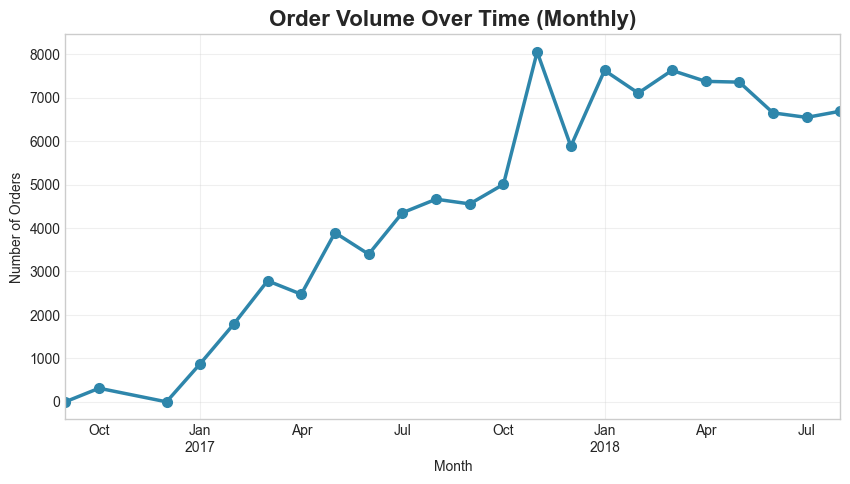

In [18]:
plt.figure(figsize=(10,5))

monthly_orders.plot(
    kind='line',
    marker='o',
    linewidth=2.5,
    markersize=7,
    color='#2E86AB'
)

plt.title('Order Volume Over Time (Monthly)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.grid(True, alpha=0.3)

plt.fill_between(range(len(monthly_orders)),
                 monthly_orders.values,
                 alpha=0.2,
                 color='#2E86AB')

plt.show()

### Revenue Over Time (Monthly)

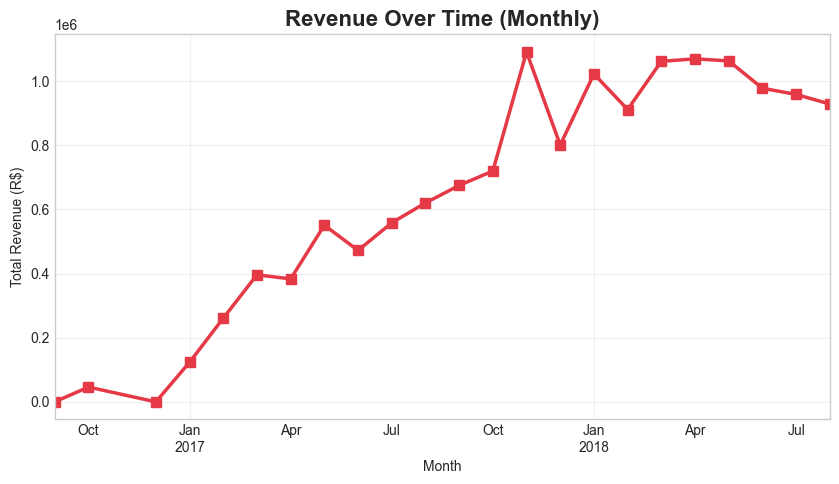

In [19]:
plt.figure(figsize=(10,5))

monthly_revenue.plot(
    kind='line',
    marker='s',
    linewidth=2.5,
    markersize=7,
    color='#E63946'
)

plt.title('Revenue Over Time (Monthly)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (R$)')
plt.grid(True, alpha=0.3)

plt.fill_between(range(len(monthly_revenue)),
                 monthly_revenue.values,
                 alpha=0.2,
                 color='#E63946')

plt.show()

**Business Insight:**

* Pronounced peaks indicate robust cyclical demand
* Surges correlate heavily with logistical stress
* Demands predictive capacity planning to avert delays

## 5. Customer & Geographic Analysis

Geographic distribution of orders and revenue reveals market concentration and guides regional expansion or optimization strategies.

In [ ]:
state_orders = df['customer_state'].value_counts().head(15)

state_revenue = df.groupby('customer_state')['order_revenue'].sum().sort_values(ascending=False).head(15)

### Top 15 States by Order Volume

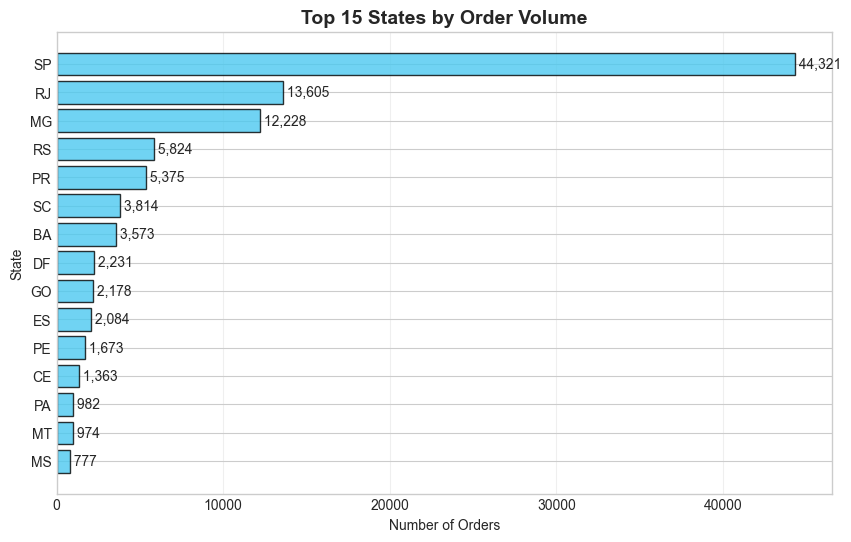

In [21]:
plt.figure(figsize=(10,6))

plt.barh(range(len(state_orders)),
         state_orders.values,
         color='#4CC9F0',
         alpha=0.8,
         edgecolor='black')

plt.yticks(range(len(state_orders)), state_orders.index)
plt.gca().invert_yaxis()

plt.title('Top 15 States by Order Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('State')
plt.grid(axis='x', alpha=0.3)

# Labels
for i, v in enumerate(state_orders.values):
    plt.text(v, i, f' {v:,}', va='center', fontsize=10)

plt.show()

### Top 15 States by Total Revenue

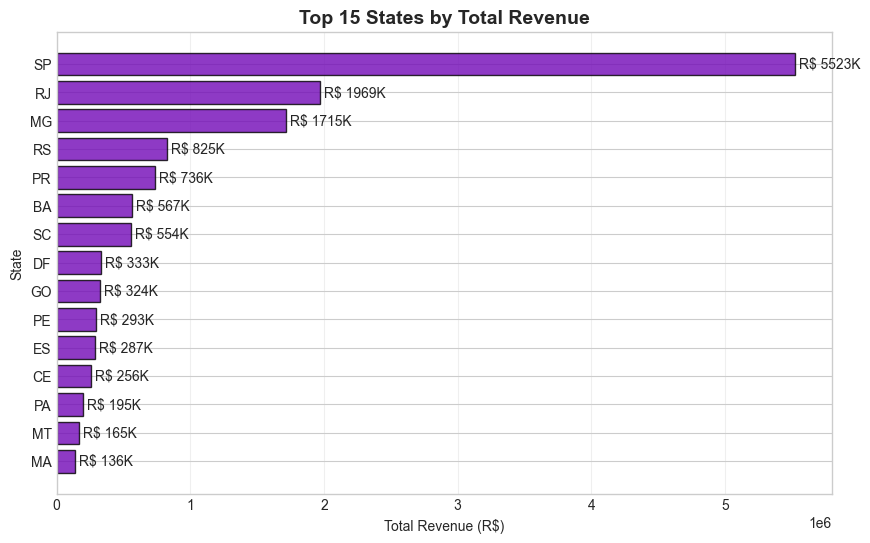

In [22]:
plt.figure(figsize=(10,6))

plt.barh(range(len(state_revenue)),
         state_revenue.values,
         color='#7209B7',
         alpha=0.8,
         edgecolor='black')

plt.yticks(range(len(state_revenue)), state_revenue.index)
plt.gca().invert_yaxis()

plt.title('Top 15 States by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('State')
plt.grid(axis='x', alpha=0.3)

# Labels
for i, v in enumerate(state_revenue.values):
    plt.text(v, i, f' R$ {v/1000:.0f}K', va='center', fontsize=10)

plt.show()

**Business Insight:**

* Core customers clearly aggregate in metropolitan centers
* Identifies strategic bases for potential distribution hubs
* Distinguishes premium from price-sensitive regions

## 6. Revenue Analysis

Deep-diving into revenue composition reveals which product categories and customer segments drive profitability.

In [23]:
category_revenue = df.groupby('product_category_name_english')['order_revenue'].agg(['sum', 'mean', 'count']).reset_index()

category_revenue.columns = ['category', 'total_revenue', 'avg_order_value', 'order_count']

top_categories = category_revenue.nlargest(15, 'total_revenue')

### Top 15 Categories by Total Revenue

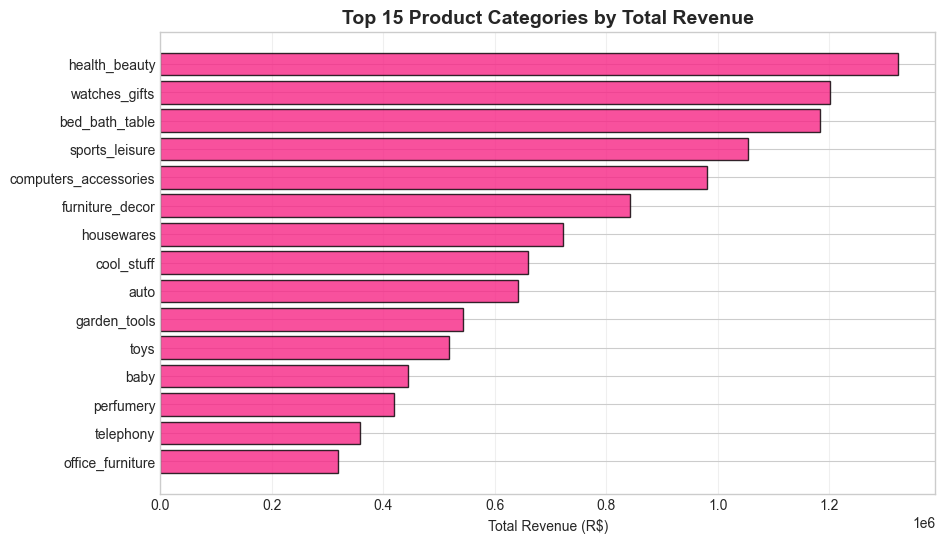

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(range(len(top_categories)),
         top_categories['total_revenue'].values,
         color='#F72585',
         alpha=0.8,
         edgecolor='black')

plt.yticks(range(len(top_categories)), top_categories['category'].values)
plt.gca().invert_yaxis()

plt.title('Top 15 Product Categories by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.grid(axis='x', alpha=0.3)

plt.show()

### Average Order Value by Top Categories

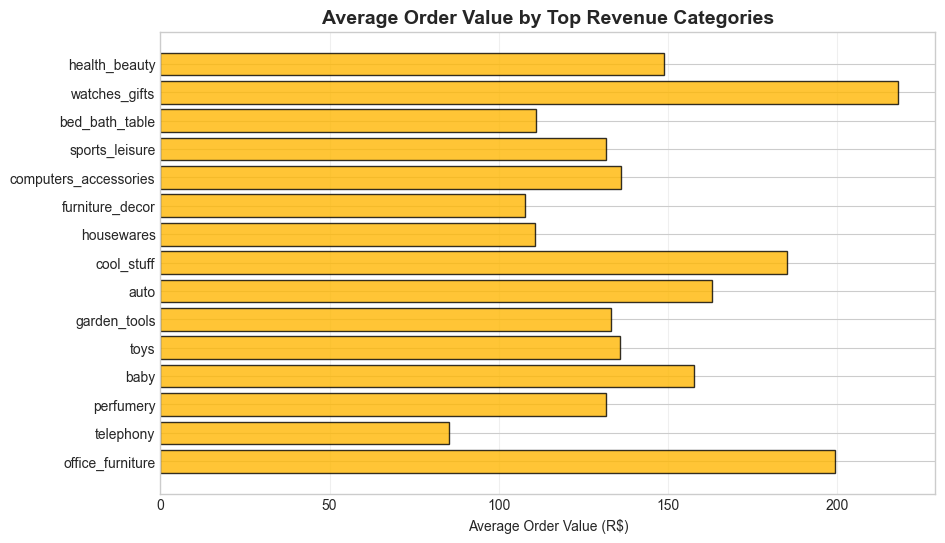

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(range(len(top_categories)),
         top_categories['avg_order_value'].values,
         color='#FFB703',
         alpha=0.8,
         edgecolor='black')

plt.yticks(range(len(top_categories)), top_categories['category'].values)
plt.gca().invert_yaxis()

plt.title('Average Order Value by Top Revenue Categories', fontsize=14, fontweight='bold')
plt.xlabel('Average Order Value (R$)')
plt.grid(axis='x', alpha=0.3)

plt.show()

**Business Insight:**

* Revenue is concentrated in a small set of product categories
* Some categories have high volume but lower order value
* Focusing on high AOV categories can maximize revenue growth

## 7. Delivery Performance Analysis

Logistics performance directly impacts customer satisfaction and churn, making it a critical operational metric.

### Delivery Performance Breakdown

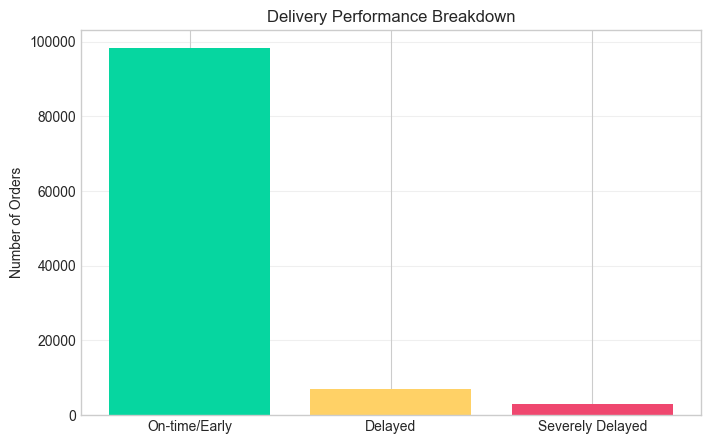

In [10]:
on_time = (df['delivery_delay_days'] <= 0).sum()
delayed = (df['delivery_delay_days'] > 0).sum()
severe = (df['delivery_delay_days'] > 7).sum()

labels = ['On-time/Early', 'Delayed', 'Severely Delayed']
values = [on_time, delayed, severe]

plt.figure(figsize=(8,5))
plt.bar(labels, values, color=['#06d6a0', '#ffd166', '#ef476f'])

plt.title('Delivery Performance Breakdown')
plt.ylabel('Number of Orders')
plt.grid(axis='y', alpha=0.3)

plt.show()

### Delivery Delay vs Churn

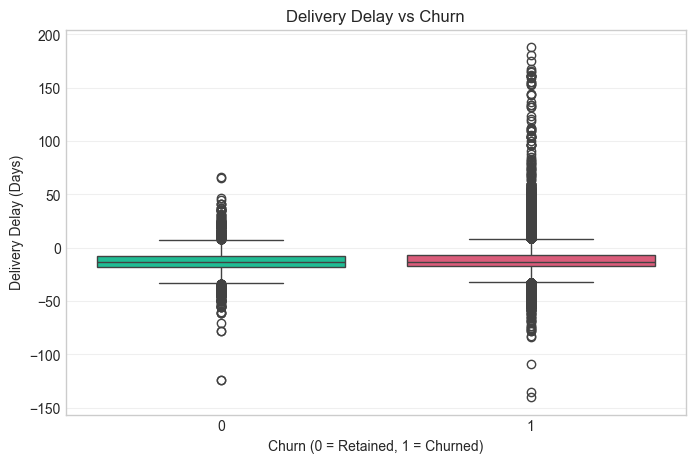

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='churn', y='delivery_delay_days',
            palette=['#06d6a0', '#ef476f'])

plt.title('Delivery Delay vs Churn')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Delivery Delay (Days)')
plt.grid(axis='y', alpha=0.3)

plt.show()

### Delay Distribution

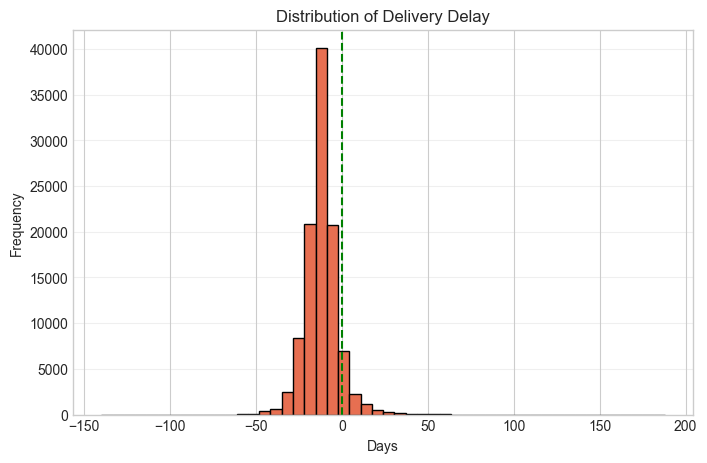

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['delivery_delay_days'], bins=50, color='#E76F51', edgecolor='black')

plt.axvline(0, color='green', linestyle='--')

plt.title('Distribution of Delivery Delay')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

**Business Insight:**

* Higher delivery delays → higher churn
* Logistics performance directly impacts retention
* Delays are a key churn driver

## 8. Customer Satisfaction & Reviews

Customer feedback provides direct insight into satisfaction drivers and early warning signals for churn risk.

### Churn Rate by Review Score

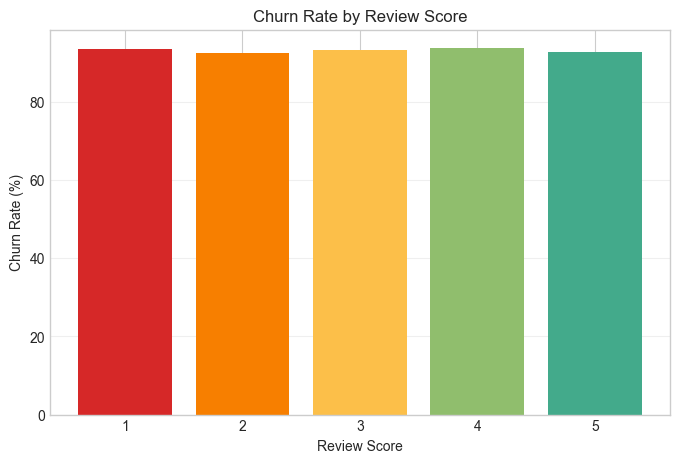

In [7]:
review_churn = df.groupby('review_score')['churn'].mean() * 100

plt.figure(figsize=(8,5))

plt.bar(review_churn.index, review_churn.values,
        color=['#d62828', '#f77f00', '#fcbf49', '#90be6d', '#43aa8b'])

plt.title('Churn Rate by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', alpha=0.3)

plt.show()

### Delivery Delay vs Review Score

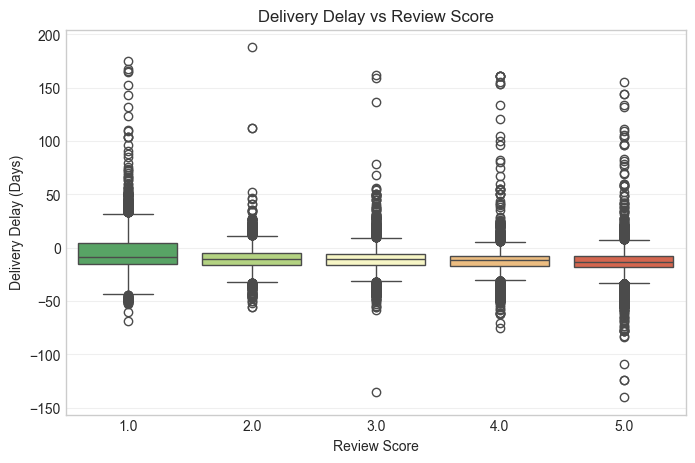

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='review_score', y='delivery_delay_days',
            palette='RdYlGn_r')

plt.title('Delivery Delay vs Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Delay (Days)')
plt.grid(axis='y', alpha=0.3)

plt.show()

### Review Distribution

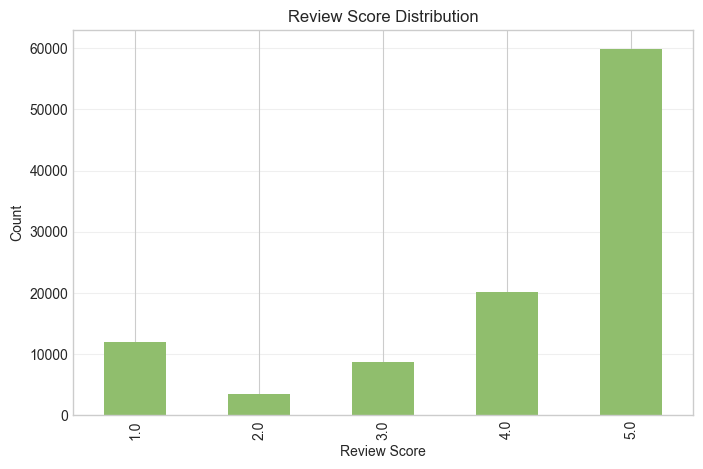

In [9]:
plt.figure(figsize=(8,5))

df['review_score'].value_counts().sort_index().plot(kind='bar',
                                                    color='#90be6d')

plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

plt.show()

**Business Insight:**

* 1-star and 2-star ratings strongly precede final disengagement
* Fulfillment bottlenecks degrade sentiment and instigate losses
* Warrants targeted intervention frameworks for at-risk accounts

## 9. Relationship Analysis

Exploring correlations and multi-variable relationships uncovers hidden patterns and validates hypotheses about driver relationships.

### A. Correlation Heatmap

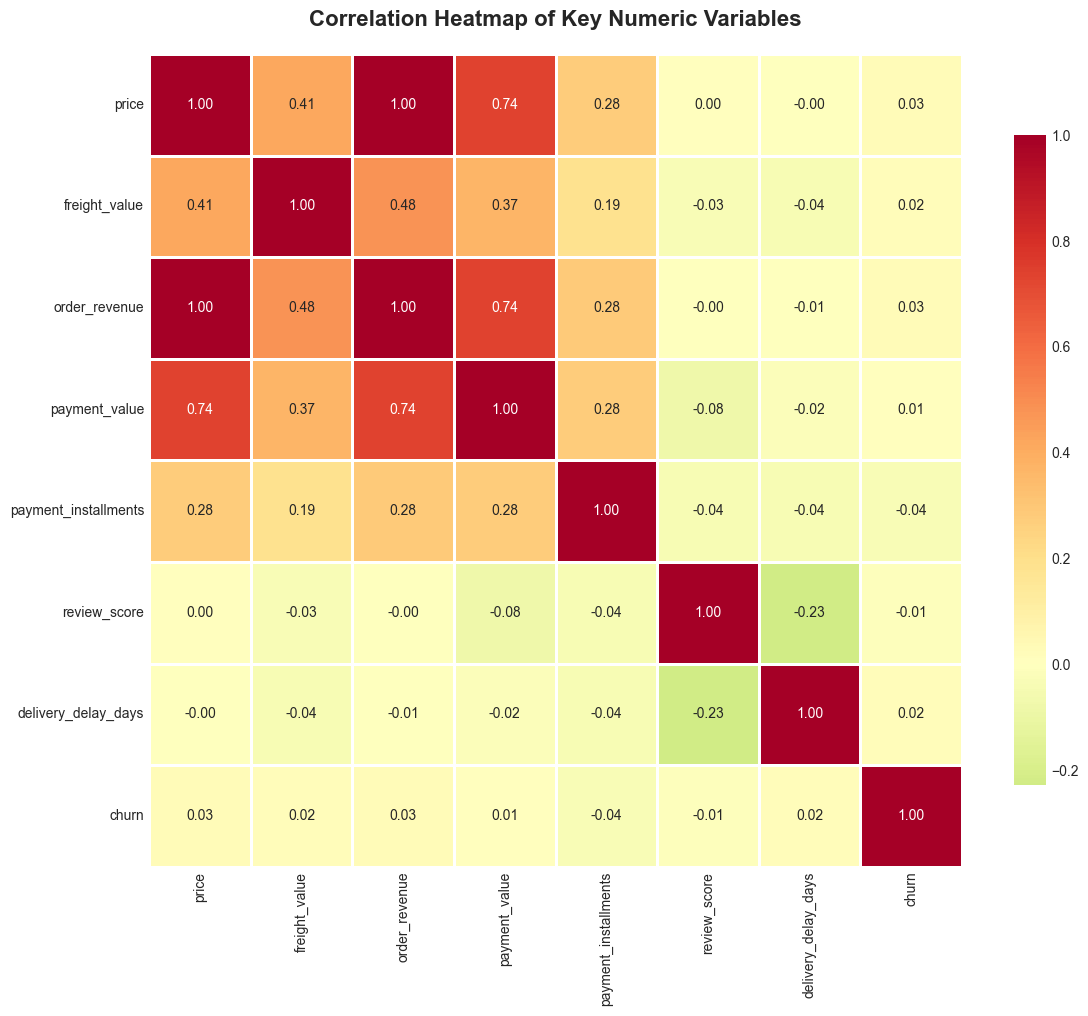

In [33]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

correlation_cols = ['price', 'freight_value', 'order_revenue', 'payment_value', 
                   'payment_installments', 'review_score', 'delivery_delay_days', 'churn']

correlation_cols = [col for col in correlation_cols if col in numeric_cols]

correlation_matrix = df[correlation_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Key Numeric Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Business Insight:**

* Positive correlation isolates delay as the leading retention threat
* Negative correlation tracks sentiment against operational lag
* Quantitatively proves poor logistics as the functional basis of churn

### B. Revenue vs Delivery Delay Scatter Plot

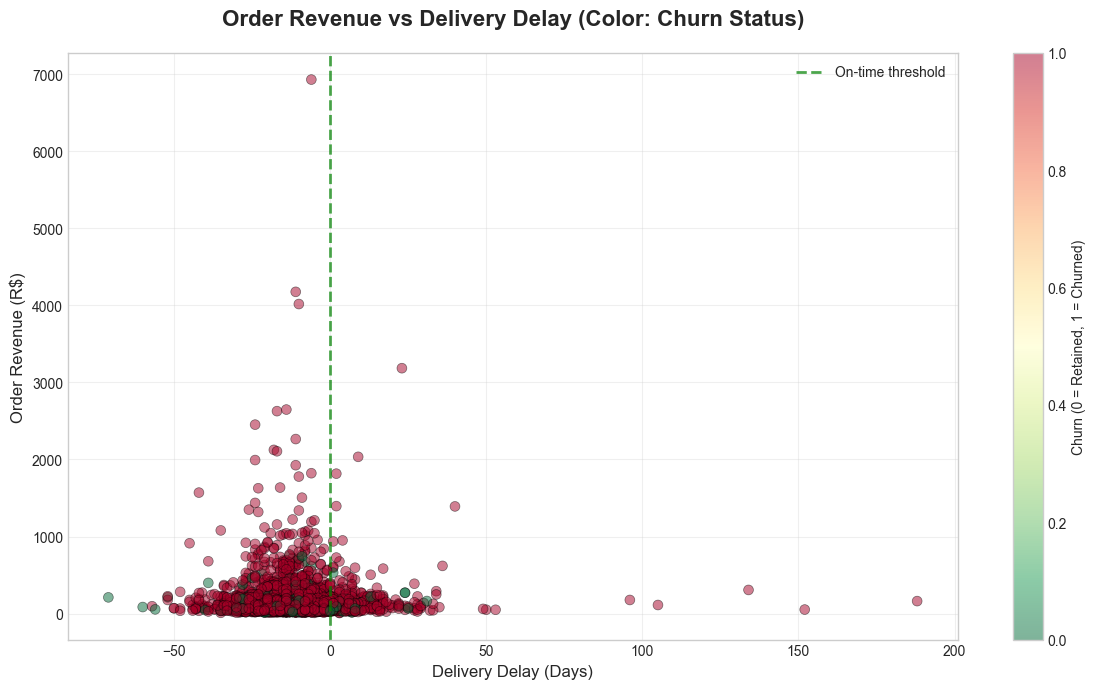

In [34]:
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

plt.figure(figsize=(12, 7))
scatter = plt.scatter(sample_df['delivery_delay_days'], sample_df['order_revenue'], 
                     c=sample_df['churn'], cmap='RdYlGn_r', alpha=0.5, s=50, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Churn (0 = Retained, 1 = Churned)')
plt.title('Order Revenue vs Delivery Delay (Color: Churn Status)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Delivery Delay (Days)', fontsize=12)
plt.ylabel('Order Revenue (R$)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(0, color='green', linestyle='--', linewidth=2, alpha=0.7, label='On-time threshold')
plt.legend()
plt.tight_layout()
plt.show()

**Business Insight:**

* High-margin accounts suffer equal exposure to delivery friction
* Churn impacts multiply when premium transactions run late
* Necessitates specific VIP delivery tiers to protect profitable cohorts

### C. State-wise Revenue Analysis

In [36]:
state_analysis = df.groupby('customer_state').agg({
    'order_revenue': 'sum',
    'order_id': 'count',
    'delivery_delay_days': 'mean',
    'churn': 'mean'
}).reset_index()

state_analysis.columns = ['state', 'total_revenue', 'order_count', 'avg_delay', 'churn_rate']
state_analysis['churn_rate'] = state_analysis['churn_rate'] * 100
top_states = state_analysis.sort_values(by='total_revenue', ascending=False).head(10)

### Revenue vs Churn Rate (Dual Axis)

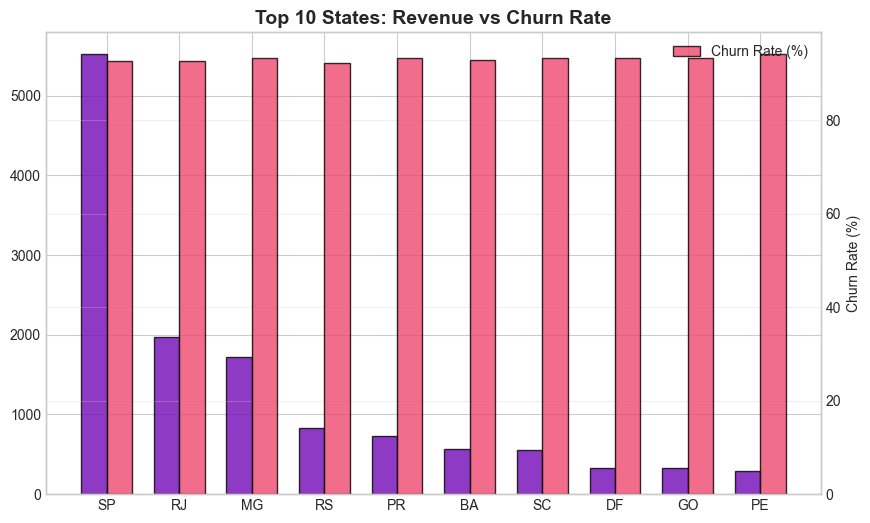

In [37]:
plt.figure(figsize=(10,6))

x = np.arange(len(top_states))
width = 0.35

# Revenue
plt.bar(x - width/2,
        top_states['total_revenue']/1000,
        width,
        label='Revenue (R$ K)',
        color='#7209B7',
        alpha=0.8,
        edgecolor='black')

# Secondary axis
ax2 = plt.gca().twinx()

ax2.bar(x + width/2,
        top_states['churn_rate'],
        width,
        label='Churn Rate (%)',
        color='#EF476F',
        alpha=0.8,
        edgecolor='black')

plt.xticks(x, top_states['state'])

plt.title('Top 10 States: Revenue vs Churn Rate', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Revenue (R$ K)')

ax2.set_ylabel('Churn Rate (%)')

plt.grid(axis='y', alpha=0.3)

# Legends
plt.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

### Average Delivery Delay by State

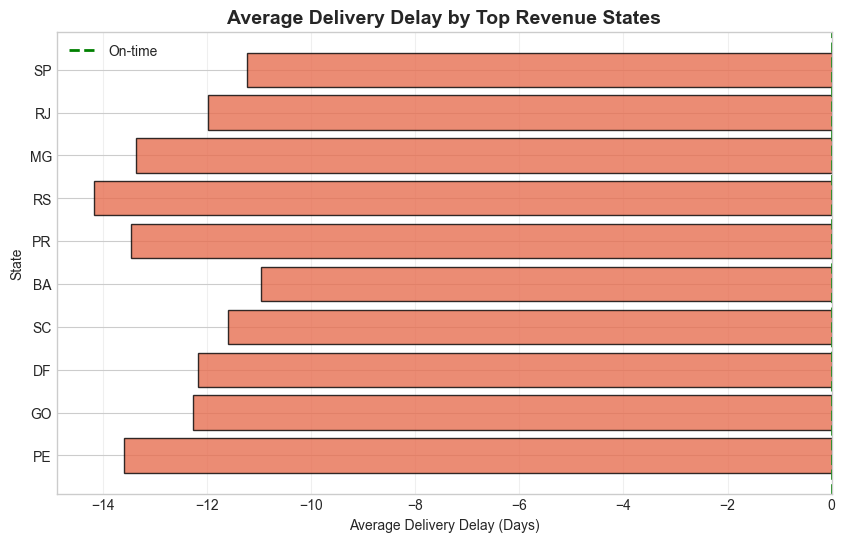

In [38]:
plt.figure(figsize=(10,6))

plt.barh(top_states['state'],
         top_states['avg_delay'],
         color='#E76F51',
         alpha=0.8,
         edgecolor='black')

plt.gca().invert_yaxis()

plt.axvline(0,
            color='green',
            linestyle='--',
            linewidth=2,
            label='On-time')

plt.title('Average Delivery Delay by Top Revenue States', fontsize=14, fontweight='bold')
plt.xlabel('Average Delivery Delay (Days)')
plt.ylabel('State')
plt.legend()
plt.grid(axis='x', alpha=0.3)

plt.show()

**Business Insight:**

* Highly lucrative states demonstrate concurrent delivery lag
* Successful marketing investments are burned by flawed logistics
* Prompts localized capital expenditure on regional dark stores

## 10. Key Findings & Business Implications

---

### Executive Directives:

**1. Address Logistics as the Core Retention Driver**
- Severely delayed orders collapse customer lifecycle value
- Deploy dedicated localized logistics efforts in critical clusters

**2. Standardize Predictive Recovery**
- 1-star ratings act as a distinct leading indicator for churn
- Initiate automatic risk-intervention workflows unconditionally

**3. Safeguard High-Value Portfolios**
- Late premium transactions amplify top-line losses rapidly
- Require automatic, expedited VIP fulfillment tiers immediately

---